# Bradley-Terry Oracle Simulation

This notebook tests the active learning algorithm when the true responses are generated by a Bradley-Terry model, rather than the frame-based model with intensity and resolvability.

**Setup:**
- True parameter: θ (weight vector)
- Oracle responds according to Bradley-Terry: P(left) = sigmoid(θ · Δx)
- Frame activation: frame i is active if (x_left[i] - x_right[i]) > 0
- Goal: See how close learned weights get to true θ

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
from typing import List, Tuple, Dict, Set, Optional
from dataclasses import dataclass
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
import seaborn as sns

from core import (
    Patient, PairwiseQuery, QueryResponse,
    FEATURE_NAMES, FEATURE_RANGES,
    sample_from_simplex, resample_from_feasible_set,
    compute_diameter, compute_frame_gaps, compute_aggregate_scores,
    predict_response, filter_samples_by_response,
    generate_random_patient, generate_candidate_queries,
    select_query_by_uncertainty, compute_frame_uncertainties,
    generate_adaptive_candidates, check_epsilon_pareto,
    active_learning_loop, active_learning_loop_adaptive,
    extract_transcript, fit_bradley_terry,
)

TAU = 0           # Intensity threshold
TAU_PRIME = 0.2     # Resolvability threshold
LAMBDA_X = 1.0      # Query scaling factor

## Define Bradley-Terry Oracle

The oracle responds based on Bradley-Terry probabilities:
- P(left preferred) = sigmoid(θ · (x_left - x_right))
- If P(left) ≈ 0.5 (within threshold), respond "indifferent"
- Otherwise respond "left" or "right" based on probability

In [106]:
def bradley_terry_oracle(query, true_weights, tau_prime= TAU_PRIME, indifference_threshold=0.0):
    """
    Oracle that responds according to Bradley-Terry model.
    
    Args:
        query: PairwiseQuery object with patient_left and patient_right
        true_weights: True weight vector θ
        indifference_threshold: If |P(left) - 0.5| < threshold, respond indifferent
    
    Returns:
        response: One of {'left', 'right', 'indifferent'}
    """
    # Get feature vectors
    x_left = query.patient_left.to_array()
    x_right = query.patient_right.to_array()
    
    # Compute feature difference
    delta_x = x_left - x_right

    # Bradley-Terry probability: P(left) = sigmoid(θ·Δx)
    logit = np.dot(true_weights, delta_x)
    p_left = expit(logit)

    # norm_delta_x = np.linalg.norm(delta_x)
    # if abs(p_left - 0.5) < indifference_threshold:
    #     if norm_delta_x < 10:
    #         return 'indifference'
    #     elif norm_delta_x >= 10:
    #         return 'incomparable'
    
    if p_left >= 0.5:
        return 'left'
    else:
        return 'right'


def get_active_frames_bt(query):
    """
    Determine active frames based on feature differences.
    Frame i is active if x_left[i] - x_right[i] > 0
    """
    x_left = query.patient_left.to_array()
    x_right = query.patient_right.to_array()
    delta_x = x_left - x_right
    
    # Active frames are those where left > right
    active_frames = set(np.where(np.abs(delta_x) > 0)[0])
    return active_frames

In [107]:
# Query selection: select_query_by_uncertainty
def select_query_by_uncertainty_bt(candidates: List[PairwiseQuery],
                                samples: np.ndarray,
                                tau: float = TAU,
                                lambda_x: float = LAMBDA_X,
                                tau_prime: float = TAU_PRIME) -> Tuple[PairwiseQuery, Dict[str, float]]:
    """
    Select the query that maximizes uncertainty (best splits the feasible set).
    
    For each candidate query, we:
    1. Predict responses for all samples in the feasible set
    2. Compute uncertainty based on response distribution
    3. Select query with highest uncertainty
    
    Uncertainty measure: entropy of response distribution
        H = -Σ p_r log(p_r) where p_r = fraction predicting response r
    
    Parameters:
    -----------
    candidates : List[PairwiseQuery]
        Candidate queries to choose from
    samples : np.ndarray, shape (n_samples, dim)
        Current feasible weight vectors
    tau : float
        Intensity threshold
    lambda_x : float
        Query scaling factor
    tau_prime : float
        Resolvability threshold
    
    Returns:
    --------
    best_query : PairwiseQuery
        Query with highest uncertainty
    info : Dict[str, float]
        Information about the selected query (uncertainty, response counts)
    """
    if len(candidates) == 0:
        raise ValueError("No candidate queries provided")
    
    if len(samples) == 0:
        # No samples - just return first candidate
        return candidates[0], {'uncertainty': 0.0}
    
    best_query = None
    best_uncertainty = -1
    best_info = {}
    
    for query in candidates:
        # Compute gaps and active frames once
        active_frames = get_active_frames_bt(query)

        # Get feature vectors
        left_features = query.patient_left.to_array()
        right_features = query.patient_right.to_array()

        # Compute gaps: Δ_j = λ(X) × (left - right)
        gaps = (left_features - right_features)
        
        if len(active_frames) == 0:
            # All samples would respond 'incomparable' - no information
            continue
        
        # Vectorized prediction for all samples
        active_list = sorted(list(active_frames))
        active_gaps = gaps[active_list]
        active_weights = samples[:, active_list]
        
        delta_omegas = np.dot(active_weights, active_gaps)
        r_omegas = np.dot(active_weights, np.abs(active_gaps))
        
        # Count responses using CORRECTED logic (matches predict_response)
        response_counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
        
        # Apply corrected decision rule
        for idx in range(len(samples)):
            r_omega = r_omegas[idx]
            delta_omega = delta_omegas[idx]
            
            if r_omega < tau:
                response_counts['indifferent'] += 1
            elif r_omega >= tau and np.abs(delta_omega) < tau_prime * r_omega:
                response_counts['incomparable'] += 1
            elif r_omega >= tau and delta_omega >= tau_prime * r_omega:
                response_counts['left'] += 1
            elif r_omega >= tau and delta_omega <= -tau_prime * r_omega:
                response_counts['right'] += 1
            else:
                response_counts['indifferent'] += 1
        
        
        # Compute entropy
        total = len(samples)
        probs = [count / total for count in response_counts.values() if count > 0]
        
        if len(probs) <= 1:
            # All samples predict same response - no uncertainty
            uncertainty = 0.0
        else:
            # Entropy: H = -Σ p log(p)
            uncertainty = -sum(p * np.log2(p) for p in probs)
        
        # Track best
        if uncertainty > best_uncertainty:
            best_uncertainty = uncertainty
            best_query = query
            best_info = {
                'uncertainty': uncertainty,
                'response_counts': response_counts.copy(),
                'active_frames': active_frames
            }
    
    if best_query is None:
        # Fallback: return first candidate
        best_query = candidates[0]
        best_info = {'uncertainty': 0.0}
    
    return best_query, best_info


## Modified Active Learning Algorithm

We need to adapt the active learning algorithm to use the Bradley-Terry oracle instead of the frame-based oracle.

In [108]:
# ADAPTIVE Main algorithm: active_learning_loop_adaptive
def active_learning_with_bt_oracle(n_initial_samples: int = 20000,
                                  epsilon_pareto: float = 0.1,
                                  max_iterations: int = 100,
                                  n_candidates: int = 50,
                                  top_k_uncertain: int = 3,
                                  min_samples: int = 100,
                                  resample_threshold: int = 0,
                                  oracle_weights: Optional[np.ndarray] = None,
                                  verbose: bool = True) -> Tuple[np.ndarray, List[Dict]]:
    """
    ADAPTIVE active learning algorithm to learn frame weights.
    
    Key differences from baseline:
    - Uses adaptive candidate generation (targets uncertain frames)
    - Uses ε-Pareto optimality as stopping criterion
    
    Algorithm:
    1. Initialize feasible set with uniform samples on simplex
    2. While NOT ε-Pareto optimal and iterations < max:
        a. Generate ADAPTIVE candidate queries (target uncertain frames)
        b. Select query with highest uncertainty
        c. Get response from oracle (user or simulated)
        d. Filter feasible set to consistent samples
        e. Resample if needed
        f. Check ε-Pareto optimality
    3. Return learned weights (mean of feasible set)
    
    Parameters:
    -----------
    n_initial_samples : int
        Initial number of samples
    epsilon_pareto : float
        ε-Pareto tolerance (stopping criterion)
    max_iterations : int
        Maximum number of queries
    n_candidates : int
        Number of candidate queries per iteration
    top_k_uncertain : int
        Focus on this many most uncertain frames
    min_samples : int
        Minimum samples to maintain
    resample_threshold : int
        Resample if samples drop below this
    oracle_weights : np.ndarray, optional
        Ground truth weights for simulation (if None, will prompt user)
    verbose : bool
        Print progress
    
    Returns:
    --------
    learned_weights : np.ndarray
        Learned frame weights (mean of feasible set)
    history : List[Dict]
        History of iterations (queries, responses, diameters, etc.)
    """
    n_features = len(FEATURE_NAMES)
    
    # Initialize feasible set
    samples = sample_from_simplex(n_initial_samples, n_features, random_state=42)
    
    history = []
    
    if verbose:
        print(f"ADAPTIVE Active Learning for Frame Weights")
        print(f"{'='*60}")
        print(f"Initial samples: {len(samples)}")
        print(f"Stopping criterion: ε-Pareto with ε = {epsilon_pareto}")
        print(f"Max iterations: {max_iterations}")
        print(f"Adaptive targeting: Top-{top_k_uncertain} uncertain frames\n")
    
    for iteration in range(max_iterations):
        # Check ε-Pareto optimality (ADAPTIVE: Decision 4 Option C)
        is_pareto, max_distance = check_epsilon_pareto(samples, epsilon_pareto)
        
        if verbose:
            print(f"Iteration {iteration + 1}")
            print(f"  Feasible samples: {len(samples)}")
            print(f"  Max L1 distance: {max_distance:.4f}")
            print(f"  ε-Pareto (ε={epsilon_pareto}): {'✓ YES' if is_pareto else '✗ NO'}")
        
        if is_pareto:
            if verbose:
                print(f"\n✓ Converged! All rules are {epsilon_pareto}-Pareto optimal")
                print(f"   (Max L1 distance {max_distance:.4f} ≤ {epsilon_pareto})")
            break
        
        # Compute frame uncertainties for monitoring
        uncertainties = compute_frame_uncertainties(samples)
        if verbose:
            top_uncertain_indices = np.argsort(uncertainties)[::-1][:top_k_uncertain]
            top_uncertain_names = [FEATURE_NAMES[i] for i in top_uncertain_indices]
            print(f"  Most uncertain frames: {top_uncertain_names}")
        
        # ADAPTIVE: Generate candidate queries targeting uncertain frames
        # (Decision 3 Option C: Adaptive to current uncertainty)
        candidates = generate_adaptive_candidates(
            samples, 
            n_candidates=n_candidates,
            top_k_uncertain=top_k_uncertain
        )
        
        if len(candidates) == 0:
            if verbose:
                print("  Warning: No valid candidates generated")
            break
        
        # Select best query (ADAPTIVE: Decision 2 Option C - Frame-targeted)
        query, query_info = select_query_by_uncertainty_bt(candidates, samples)
        
        if verbose:
            print(f"  Query uncertainty: {query_info.get('uncertainty', 0):.3f} bits")
            print(f"  Active frames: {sorted(query_info.get('active_frames', set()))}")
        
        # Get response from oracle
        if oracle_weights is not None:
            # Simulated response
            response = bradley_terry_oracle(query, oracle_weights, tau_prime = 10, indifference_threshold=0)
        else:
            # Would prompt user here
            print(f"\n{query}")
            print("Please respond: left/right/indifferent/incomparable")
            response = input("Response: ").strip().lower()
        
        if verbose:
            print(f"  Response: {response}")
        
        # Filter samples
        samples_before = len(samples)
        samples = filter_samples_by_response(samples, query, response)
        samples_after = len(samples)
        
        if verbose:
            print(f"  Filtered: {samples_before} → {samples_after} samples")
        
        # Resample if needed
        if samples_after < resample_threshold and samples_after > 0:
            samples = resample_from_feasible_set(samples, min_samples)
            if verbose:
                print(f"  Resampled to {len(samples)} samples")
        elif samples_after == 0:
            if verbose:
                print("  ERROR: No consistent samples remain!")
            break
        
        # Record history
        history.append({
            'iteration': iteration + 1,
            'query': query,
            'response': response,
            'max_distance': max_distance,
            'is_epsilon_pareto': is_pareto,
            'n_samples': samples_after,
            'uncertainty': query_info.get('uncertainty', 0),
            'active_frames': query_info.get('active_frames', set()),
            'frame_uncertainties': uncertainties.copy()
        })
        
        if verbose:
            print()
    
    # Compute learned weights
    learned_weights = samples.mean(axis=0)
    
    if verbose:
        print(f"\nLearned weights:")
        for i, (name, weight) in enumerate(zip(FEATURE_NAMES, learned_weights)):
            print(f"  {name:20s}: {weight:.4f}")
        
        if oracle_weights is not None:
            print(f"\nGround truth weights:")
            for i, (name, weight) in enumerate(zip(FEATURE_NAMES, oracle_weights)):
                print(f"  {name:20s}: {weight:.4f}")
            
            l1_error = np.abs(learned_weights - oracle_weights).sum()
            print(f"\nL1 error: {l1_error:.4f}")
    
    return learned_weights, history


## Run Simulation

Set true Bradley-Terry weights and run the active learning algorithm.

In [109]:
# Set random seed for reproducibility
np.random.seed(56)

# Define true Bradley-Terry weights (normalized)
n_features = 5
true_weights = np.array([0.3, 0.25, 0.2, 0.15, 0.1])
true_weights = true_weights / np.sum(true_weights)  # Normalize to sum to 1

print("True Bradley-Terry weights:")
feature_names = FEATURE_NAMES
for i, (name, weight) in enumerate(zip(feature_names, true_weights)):
    print(f"  {name}: {weight:.3f}")

# Feature bounds (all features between 0 and 100)
feature_bounds = [(0, 100)] * n_features

True Bradley-Terry weights:
  elderlyDep: 0.300
  lifeYearsGained: 0.250
  obesity: 0.200
  weeklyWorkhours: 0.150
  yearsWaiting: 0.100


In [110]:
# Run active learning with Bradley-Terry oracle
learned_weights, history_bt = active_learning_with_bt_oracle(
    n_initial_samples=10000,
    epsilon_pareto=0.15,
    max_iterations=50,
    n_candidates=100,
    top_k_uncertain=3,
    resample_threshold=0,
    oracle_weights=true_weights,
    verbose=True
    
)

ADAPTIVE Active Learning for Frame Weights
Initial samples: 10000
Stopping criterion: ε-Pareto with ε = 0.15
Max iterations: 50
Adaptive targeting: Top-3 uncertain frames

Iteration 1
  Feasible samples: 10000
  Max L1 distance: 1.7478
  ε-Pareto (ε=0.15): ✗ NO
  Most uncertain frames: ['weeklyWorkhours', 'elderlyDep', 'obesity']
  Query uncertainty: 1.771 bits
  Active frames: [0, 1, 2, 3, 4]
  Response: left
  Filtered: 10000 → 3291 samples

Iteration 2
  Feasible samples: 3291
  Max L1 distance: 1.5296
  ε-Pareto (ε=0.15): ✗ NO
  Most uncertain frames: ['elderlyDep', 'weeklyWorkhours', 'yearsWaiting']
  Query uncertainty: 1.830 bits
  Active frames: [0, 1, 2, 4]
  Response: right
  Filtered: 3291 → 1188 samples

Iteration 3
  Feasible samples: 1188
  Max L1 distance: 1.0185
  ε-Pareto (ε=0.15): ✗ NO
  Most uncertain frames: ['weeklyWorkhours', 'elderlyDep', 'yearsWaiting']
  Query uncertainty: 1.411 bits
  Active frames: [0, 1, 2, 3, 4]
  Response: right
  Filtered: 1188 → 466 sampl

/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_3144/414115720.py:163: RuntimeWarning: Mean of empty slice.
  learned_weights = samples.mean(axis=0)


## Visualize Results

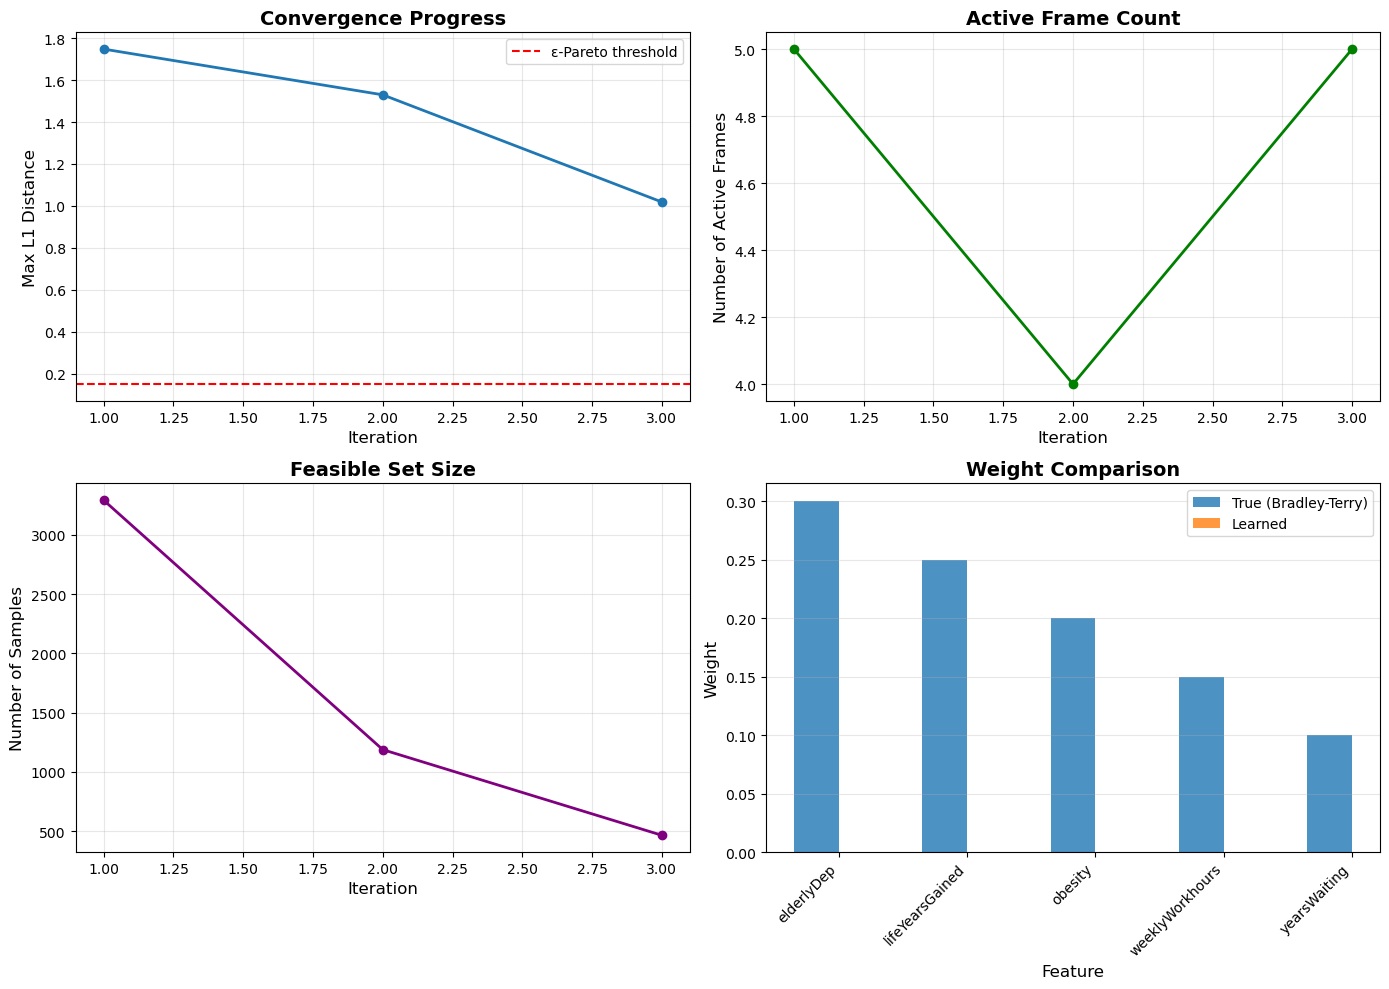


=== Final Statistics ===
Total iterations: 3
Final max L1 distance: 1.0185
L1 error: nan
L2 error: nan

True weights:    [0.3  0.25 0.2  0.15 0.1 ]
Learned weights: [nan nan nan nan nan]


In [111]:
# Plot learning progress
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

iterations = [h['iteration'] for h in history_bt]
max_distances = [h['max_distance'] for h in history_bt]
n_samples_list = [h['n_samples'] for h in history_bt]
n_active_frames = [len(h['active_frames']) for h in history_bt]

# Plot 1: Max L1 distance (convergence)
ax = axes[0, 0]
ax.plot(iterations, max_distances, 'o-', linewidth=2, markersize=6)
ax.axhline(y=0.15, color='r', linestyle='--', label='ε-Pareto threshold')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Max L1 Distance', fontsize=12)
ax.set_title('Convergence Progress', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Number of active frames
ax = axes[0, 1]
ax.plot(iterations, n_active_frames, 'o-', color='green', linewidth=2, markersize=6)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Number of Active Frames', fontsize=12)
ax.set_title('Active Frame Count', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 3: Sample count
ax = axes[1, 0]
ax.plot(iterations, n_samples_list, 'o-', color='purple', linewidth=2, markersize=6)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Feasible Set Size', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 4: Weight comparison
ax = axes[1, 1]
x = np.arange(len(feature_names))
width = 0.35
ax.bar(x - width/2, true_weights, width, label='True (Bradley-Terry)', alpha=0.8)
ax.bar(x + width/2, learned_weights, width, label='Learned', alpha=0.8)
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Weight', fontsize=12)
ax.set_title('Weight Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print final statistics
print("\n=== Final Statistics ===")
print(f"Total iterations: {len(history_bt)}")
print(f"Final max L1 distance: {max_distances[-1]:.4f}")
print(f"L1 error: {np.sum(np.abs(learned_weights - true_weights)):.4f}")
print(f"L2 error: {np.linalg.norm(learned_weights - true_weights):.4f}")
print(f"\nTrue weights:    {true_weights}")
print(f"Learned weights: {learned_weights}")

## Response Distribution

Analyze the types of responses received from the Bradley-Terry oracle.

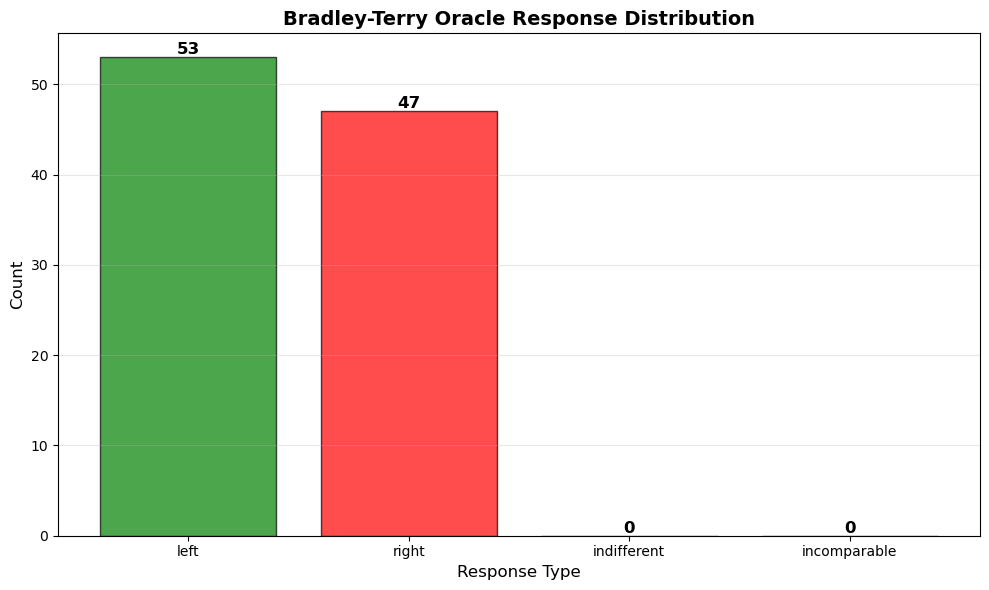


=== Response Distribution ===
left        :  53 ( 53.0%)
right       :  47 ( 47.0%)
indifferent :   0 (  0.0%)
incomparable:   0 (  0.0%)


In [112]:
# Count response types
response_counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
for query, response in transcript_bt:
    response_counts[response] += 1

# Plot response distribution
fig, ax = plt.subplots(figsize=(10, 6))
responses = list(response_counts.keys())
counts = list(response_counts.values())
colors = ['green', 'red', 'gray', 'orange']

bars = ax.bar(responses, counts, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Response Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Bradley-Terry Oracle Response Distribution', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== Response Distribution ===")
total = sum(counts)
for response, count in response_counts.items():
    percentage = (count / total) * 100 if total > 0 else 0
    print(f"{response:12s}: {count:3d} ({percentage:5.1f}%)")

## Frame Activation Analysis

Visualize which frames were activated throughout the learning process.

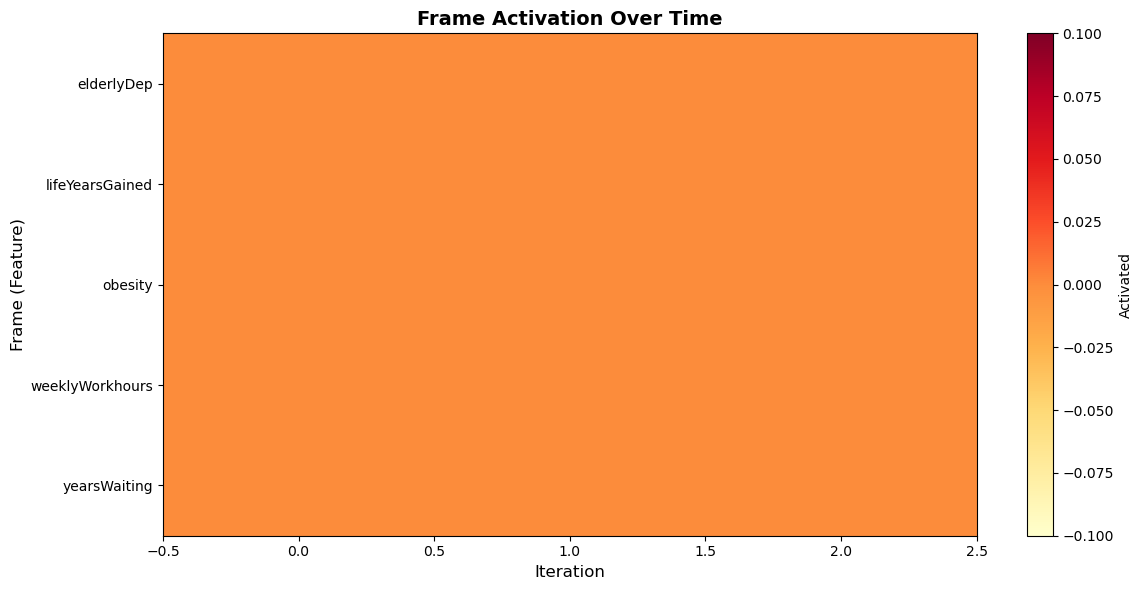


=== Frame Activation Statistics ===
elderlyDep: 0.00% of queries
lifeYearsGained: 0.00% of queries
obesity: 0.00% of queries
weeklyWorkhours: 0.00% of queries
yearsWaiting: 0.00% of queries


In [113]:
# Create frame activation heatmap
frame_activation = np.zeros((len(history_bt), n_features))
for i, h in enumerate(history_bt):
    active = h.get('query_active_frames', set())
    for frame_idx in active:
        if frame_idx < n_features:
            frame_activation[i, frame_idx] = 1

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(frame_activation.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Frame (Feature)', fontsize=12)
ax.set_title('Frame Activation Over Time', fontsize=14, fontweight='bold')
ax.set_yticks(range(n_features))
ax.set_yticklabels(feature_names)
plt.colorbar(im, ax=ax, label='Activated')
plt.tight_layout()
plt.show()

# Print activation statistics
print("\n=== Frame Activation Statistics ===")
activation_freq = np.sum(frame_activation, axis=0) / len(history_bt)
for i, (name, freq) in enumerate(zip(feature_names, activation_freq)):
    print(f"{name}: {freq:.2%} of queries")